In [1]:
%pip install -q --upgrade pip setuptools wheel

%pip install -q --no-cache-dir \
  "docling" \
  "reportlab" \
  "pyyaml" \
  "pillow"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer-slim 0.24.0 requires typer>=0.24.0, but you have typer 0.21.2 which is incompatible.


In [1]:
import os

# Force CPU to avoid CUDA / NVRTC errors in Colab
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["TORCHDYNAMO_DISABLE"] = "1"

import json
import yaml
import time
import getpass
from pathlib import Path

import PIL
from PIL import Image, ImageDraw, ImageFont

from reportlab.pdfgen import canvas
from reportlab.lib.pagesizes import letter

from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.datamodel.base_models import InputFormat

print("Pillow:", PIL.__version__)
print("All imports worked.")

Pillow: 11.3.0
All imports worked.


In [2]:
INPUT_DIR = Path("enrichment_inputs")
OUTPUT_DIR = Path("enrichment_outputs")

INPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Input folder:", INPUT_DIR.resolve())
print("Output folder:", OUTPUT_DIR.resolve())

Input folder: /content/enrichment_inputs
Output folder: /content/enrichment_outputs


In [3]:
def save_json(data, path):
    path = Path(path)
    path.write_text(
        json.dumps(data, indent=2, ensure_ascii=False, default=str),
        encoding="utf-8"
    )
    print("Saved:", path)


def save_text(text, path):
    path = Path(path)
    path.write_text(text, encoding="utf-8")
    print("Saved:", path)


def recursive_find(data, keywords, path="root"):
    results = []

    if isinstance(data, dict):
        for key, value in data.items():
            key_text = str(key).lower()

            if any(keyword.lower() in key_text for keyword in keywords):
                results.append({
                    "path": f"{path}.{key}",
                    "value": value
                })

            results.extend(
                recursive_find(value, keywords, f"{path}.{key}")
            )

    elif isinstance(data, list):
        for index, item in enumerate(data):
            results.extend(
                recursive_find(item, keywords, f"{path}[{index}]")
            )

    return results


def summarize_picture_items(doc_dict):
    summaries = []

    if isinstance(doc_dict, dict) and "pictures" in doc_dict:
        pictures = doc_dict["pictures"]

        if isinstance(pictures, list):
            for index, picture in enumerate(pictures, start=1):
                if isinstance(picture, dict):
                    summaries.append({
                        "picture_index": index,
                        "label": picture.get("label"),
                        "caption": picture.get("caption"),
                        "annotations": picture.get("annotations"),
                        "prov": picture.get("prov"),
                        "raw": picture,
                    })

    return summaries

Created: enrichment_inputs/sales_bar_chart.png


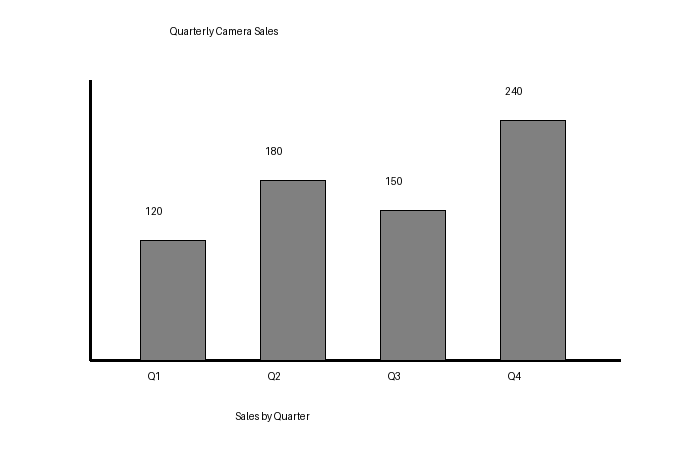

In [4]:
chart_path = INPUT_DIR / "sales_bar_chart.png"

img = Image.new("RGB", (700, 450), "white")
draw = ImageDraw.Draw(img)

try:
    title_font = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        32
    )
    font = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        22
    )
except:
    title_font = None
    font = None

draw.text((170, 25), "Quarterly Camera Sales", fill="black", font=title_font)

# Axes
draw.line((90, 360, 620, 360), fill="black", width=3)
draw.line((90, 80, 90, 360), fill="black", width=3)

labels = ["Q1", "Q2", "Q3", "Q4"]
values = [120, 180, 150, 240]
max_value = max(values)

bar_x = [140, 260, 380, 500]
bar_width = 65

for x, label, value in zip(bar_x, labels, values):
    bar_height = int((value / max_value) * 240)
    y_top = 360 - bar_height

    draw.rectangle(
        (x, y_top, x + bar_width, 360),
        fill="gray",
        outline="black"
    )

    draw.text((x + 8, 370), label, fill="black", font=font)
    draw.text((x + 5, y_top - 35), str(value), fill="black", font=font)

draw.text((235, 410), "Sales by Quarter", fill="black", font=font)

img.save(chart_path, format="PNG")

print("Created:", chart_path)
display(img)

Created: enrichment_inputs/order_process_flow.png


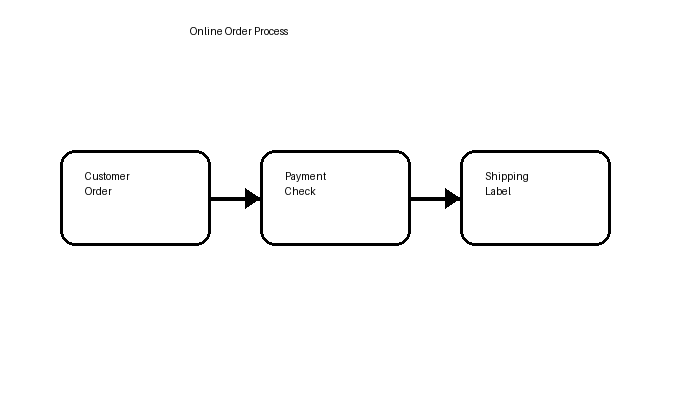

In [5]:
flow_path = INPUT_DIR / "order_process_flow.png"

img = Image.new("RGB", (700, 420), "white")
draw = ImageDraw.Draw(img)

try:
    title_font = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        30
    )
    font = ImageFont.truetype(
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        22
    )
except:
    title_font = None
    font = None

draw.text((190, 25), "Online Order Process", fill="black", font=title_font)

boxes = [
    ("Customer\nOrder", 60, 150),
    ("Payment\nCheck", 260, 150),
    ("Shipping\nLabel", 460, 150),
]

for text, x, y in boxes:
    draw.rounded_rectangle(
        (x, y, x + 150, y + 95),
        radius=15,
        outline="black",
        width=3
    )
    draw.multiline_text(
        (x + 25, y + 20),
        text,
        fill="black",
        font=font,
        spacing=5
    )

# Arrows
draw.line((210, 198, 260, 198), fill="black", width=4)
draw.polygon([(260, 198), (245, 188), (245, 208)], fill="black")

draw.line((410, 198, 460, 198), fill="black", width=4)
draw.polygon([(460, 198), (445, 188), (445, 208)], fill="black")

img.save(flow_path, format="PNG")

print("Created:", flow_path)
display(img)

In [6]:
sample_pdf_path = INPUT_DIR / "sample_pictures_document.pdf"

pdf = canvas.Canvas(str(sample_pdf_path), pagesize=letter)
width, height = letter

# Page 1
pdf.setFont("Helvetica-Bold", 18)
pdf.drawString(72, height - 72, "Document Enrichment Example")

pdf.setFont("Helvetica", 11)
pdf.drawString(
    72,
    height - 100,
    "This PDF contains pictures that will be classified and described using Docling enrichment."
)

pdf.setFont("Helvetica-Bold", 14)
pdf.drawString(72, height - 135, "Figure 1: Bar Chart")

pdf.drawImage(
    str(chart_path),
    72,
    height - 430,
    width=420,
    height=270
)

pdf.showPage()

# Page 2
pdf.setFont("Helvetica-Bold", 18)
pdf.drawString(72, height - 72, "Second Page")

pdf.setFont("Helvetica-Bold", 14)
pdf.drawString(72, height - 115, "Figure 2: Flow Diagram")

pdf.drawImage(
    str(flow_path),
    72,
    height - 410,
    width=420,
    height=250
)

pdf.save()

print("Created PDF:", sample_pdf_path)

Created PDF: enrichment_inputs/sample_pictures_document.pdf


In [7]:
classification_options = PdfPipelineOptions()

classification_options.generate_picture_images = True
classification_options.images_scale = 2
classification_options.do_picture_classification = True

classification_converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=classification_options
        )
    }
)

print("Picture classification pipeline is ready.")

Picture classification pipeline is ready.


In [8]:
start = time.time()

classification_result = classification_converter.convert(sample_pdf_path)

end = time.time()

classification_doc = classification_result.document

print("Status:", classification_result.status)
print(f"Time: {end - start:.2f} seconds")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

[INFO] 2026-04-30 08:53:14,563 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-04-30 08:53:14,572 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-04-30 08:53:14,577 [RapidOCR] download_file.py:68: Initiating download: https://www.modelscope.cn/models/RapidAI/RapidOCR/resolve/v3.8.0/torch/PP-OCRv4/det/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-04-30 08:53:15,441 [RapidOCR] download_file.py:82: Download size: 13.83MB
[INFO] 2026-04-30 08:53:15,965 [RapidOCR] download_file.py:95: Successfully saved to: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-04-30 08:53:15,970 [RapidOCR] main.py:50: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-04-30 08:53:16,823 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-04-30 08:53:16,825 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-04-30 08:53:16,831 [RapidOCR] download_file.py:68: Initiating download: https

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

Status: ConversionStatus.SUCCESS
Time: 65.77 seconds


In [9]:
classification_dict = classification_doc.export_to_dict()
classification_markdown = classification_doc.export_to_markdown()

save_json(
    classification_dict,
    OUTPUT_DIR / "task1_picture_classification_result.json"
)

save_text(
    classification_markdown,
    OUTPUT_DIR / "task1_picture_classification_result.md"
)

print(classification_markdown[:2000])

Saved: enrichment_outputs/task1_picture_classification_result.json
Saved: enrichment_outputs/task1_picture_classification_result.md
## Document Enrichment Example

This PDF contains pictures that will be classified and described using Docling enrichment.

Figure 1: Bar Chart

Quarterly Camera Sales

Bar chart

<!-- image -->

## Second Page

## Figure 2: Flow Diagram

Flow chart

<!-- image -->


Number of matched fields: 138

PATH: root.furniture.label
VALUE: unspecified

PATH: root.body.label
VALUE: unspecified

PATH: root.texts[0].label
VALUE: section_header

PATH: root.texts[1].label
VALUE: text

PATH: root.texts[2].label
VALUE: caption

PATH: root.texts[3].label
VALUE: text

PATH: root.texts[4].label
VALUE: text

PATH: root.texts[5].label
VALUE: text

PATH: root.texts[6].label
VALUE: text

PATH: root.texts[7].label
VALUE: text

PATH: root.texts[8].label
VALUE: text

PATH: root.texts[9].label
VALUE: text

PATH: root.texts[10].label
VALUE: text

PATH: root.texts[11].label
VALUE: text

PATH: root.texts[12].label
VALUE: text

PATH: root.texts[13].label
VALUE: section_header

PATH: root.texts[14].label
VALUE: section_header

PATH: root.texts[15].label
VALUE: text

PATH: root.texts[16].label
VALUE: text

PATH: root.texts[17].label
VALUE: text

PATH: root.texts[18].label
VALUE: text

PATH: root.texts[19].label
VALUE: text

PATH: root.texts[20].label
VALUE: text

PATH: root.pictur
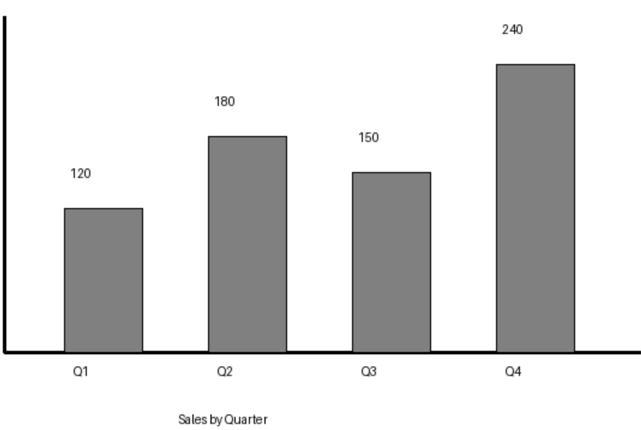
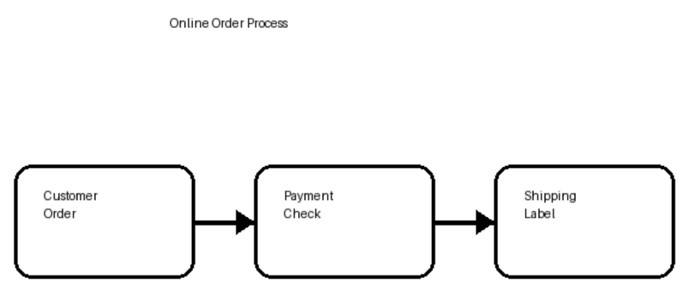

In [10]:
classification_matches = recursive_find(
    classification_dict,
    keywords=[
        "class",
        "classification",
        "picture",
        "annotation",
        "label",
        "caption"
    ]
)

print("Number of matched fields:", len(classification_matches))

for item in classification_matches[:100]:
    print("\nPATH:", item["path"])
    print("VALUE:", item["value"])

In [11]:
picture_classification_summary = summarize_picture_items(classification_dict)

save_json(
    picture_classification_summary,
    OUTPUT_DIR / "task1_picture_classification_summary.json"
)

print("Pictures found:", len(picture_classification_summary))

for pic in picture_classification_summary:
    print("\nPicture:", pic["picture_index"])
    print("Label:", pic["label"])
    print("Caption:", pic["caption"])
    print("Annotations:", pic["annotations"])

Saved: enrichment_outputs/task1_picture_classification_summary.json
Pictures found: 2

Picture: 1
Label: picture
Caption: None
Annotations: [{'kind': 'classification', 'provenance': 'DocumentPictureClassifier', 'predicted_classes': [{'class_name': 'bar_chart', 'confidence': 0.998129665851593}, {'class_name': 'table', 'confidence': 0.0014087747549638152}, {'class_name': 'line_chart', 'confidence': 0.0002547177718952298}, {'class_name': 'engineering_drawing', 'confidence': 6.315147766144946e-05}, {'class_name': 'calendar', 'confidence': 3.333674612804316e-05}, {'class_name': 'pie_chart', 'confidence': 3.1438135920325294e-05}, {'class_name': 'other', 'confidence': 1.6591651728958823e-05}, {'class_name': 'screenshot_from_computer', 'confidence': 1.596802940184716e-05}, {'class_name': 'box_plot', 'confidence': 1.4209874279913493e-05}, {'class_name': 'flow_chart', 'confidence': 9.522252184979152e-06}, {'class_name': 'screenshot_from_manual', 'confidence': 7.048446150292875e-06}, {'class_name

#Task 2: Picture Description


In [15]:
from docling.datamodel.pipeline_options import PictureDescriptionApiOptions

openrouter_key = getpass.getpass("Paste your OpenRouter API key: ").strip()

description_options = PdfPipelineOptions()

description_options.generate_picture_images = True
description_options.images_scale = 2
description_options.do_picture_description = True
description_options.enable_remote_services = True

description_options.picture_description_options = PictureDescriptionApiOptions(
    url="https://openrouter.ai/api/v1/chat/completions",
    headers={
        "Authorization": f"Bearer {openrouter_key}",
        "HTTP-Referer": "https://colab.research.google.com",
        "X-OpenRouter-Title": "Docling Enrichment Exercise",
    },
    params={
        "model": "openrouter/free",
        "max_tokens": 250,
    },
    prompt="Describe this document image or figure in two short, accurate sentences.",
    timeout=120,
)

description_converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=description_options
        )
    }
)

print("Remote picture description pipeline is ready.")

Paste your OpenRouter API key: ··········
Remote picture description pipeline is ready.


In [16]:
start = time.time()

description_result = description_converter.convert(sample_pdf_path)

end = time.time()

description_doc = description_result.document

print("Status:", description_result.status)
print(f"Time: {end - start:.2f} seconds")

[INFO] 2026-04-30 08:56:15,554 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-04-30 08:56:15,555 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-04-30 08:56:15,605 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-04-30 08:56:15,607 [RapidOCR] main.py:50: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-04-30 08:56:17,359 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-04-30 08:56:17,361 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-04-30 08:56:17,374 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-04-30 08:56:17,378 [RapidOCR] main.py:50: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-04-30 08:56:17,571 [Ra

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

ERROR:docling.utils.api_image_request:Error calling the API. Response was {"error":{"message":"Provider returned error","code":429,"metadata":{"raw":"google/gemma-4-26b-a4b-it:free is temporarily rate-limited upstream. Please retry shortly, or add your own key to accumulate your rate limits: https://openrouter.ai/settings/integrations","provider_name":"Google AI Studio","is_byok":false}},"user_id":"user_3CyxOMN82i7plnFgPeaWuSlUokQ"}
ERROR:docling.utils.api_image_request:Error, could not process request: 4 validation errors for OpenAiApiResponse
id
  Field required [type=missing, input_value={'error': {'message': 'Pr...MN82i7plnFgPeaWuSlUokQ'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
choices
  Field required [type=missing, input_value={'error': {'message': 'Pr...MN82i7plnFgPeaWuSlUokQ'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
created
  Field required [type=missing, input_value={'

Status: ConversionStatus.SUCCESS
Time: 43.80 seconds


In [17]:
description_dict = description_doc.export_to_dict()
description_markdown = description_doc.export_to_markdown()

save_json(
    description_dict,
    OUTPUT_DIR / "task2_picture_description_result.json"
)

save_text(
    description_markdown,
    OUTPUT_DIR / "task2_picture_description_result.md"
)

print(description_markdown[:2500])

Saved: enrichment_outputs/task2_picture_description_result.json
Saved: enrichment_outputs/task2_picture_description_result.md
## Document Enrichment Example

This PDF contains pictures that will be classified and described using Docling enrichment.

Figure 1: Bar Chart

Quarterly Camera Sales

<!-- image -->

## Second Page

## Figure 2: Flow Diagram

<!-- image -->


Number of matched fields: 33

PATH: root.texts
VALUE: [{'self_ref': '#/texts/0', 'parent': {'$ref': '#/body'}, 'children': [], 'content_layer': 'body', 'label': 'section_header', 'prov': [{'page_no': 1, 'bbox': {'l': 72.0, 't': 732.924, 'r': 343.06200000000007, 'b': 716.274, 'coord_origin': 'BOTTOMLEFT'}, 'charspan': [0, 27]}], 'orig': 'Document Enrichment Example', 'text': 'Document Enrichment Example', 'level': 1}, {'self_ref': '#/texts/1', 'parent': {'$ref': '#/body'}, 'children': [], 'content_layer': 'body', 'label': 'text', 'prov': [{'page_no': 1, 'bbox': {'l': 72.0, 't': 699.898, 'r': 508.4909999999999, 'b': 689.723, 'coord_origin': 'BOTTOMLEFT'}, 'charspan': [0, 90]}], 'orig': 'This PDF contains pictures that will be classified and described using Docling enrichment.', 'text': 'This PDF contains pictures that will be classified and described using Docling enrichment.'}, {'self_ref': '#/texts/2', 'parent': {'$ref': '#/body'}, 'children': [], 'content_layer': 'body', 'label': 'cap
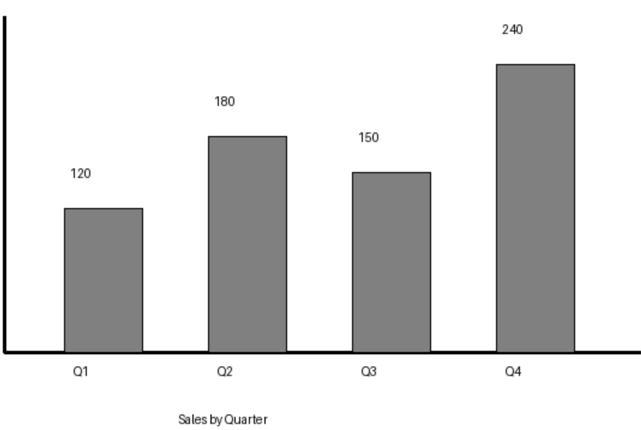
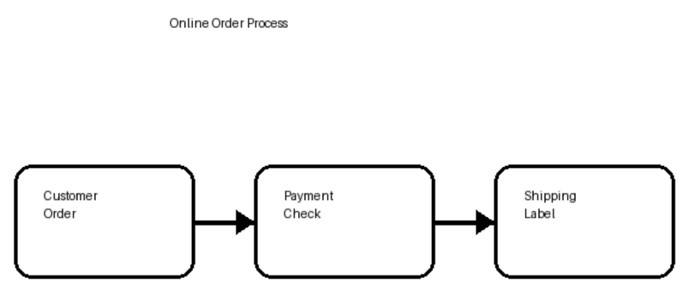

In [18]:
description_matches = recursive_find(
    description_dict,
    keywords=[
        "description",
        "caption",
        "annotation",
        "picture",
        "text"
    ]
)

print("Number of matched fields:", len(description_matches))

for item in description_matches[:120]:
    print("\nPATH:", item["path"])
    print("VALUE:", item["value"])

In [19]:
picture_description_summary = summarize_picture_items(description_dict)

save_json(
    picture_description_summary,
    OUTPUT_DIR / "task2_picture_description_summary.json"
)

print("Pictures found:", len(picture_description_summary))

for pic in picture_description_summary:
    print("\nPicture:", pic["picture_index"])
    print("Label:", pic["label"])
    print("Caption:", pic["caption"])
    print("Annotations:", pic["annotations"])

Saved: enrichment_outputs/task2_picture_description_summary.json
Pictures found: 2

Picture: 1
Label: picture
Caption: None
Annotations: [{'kind': 'description', 'text': '', 'provenance': 'not-implemented'}]

Picture: 2
Label: picture
Caption: None
Annotations: [{'kind': 'description', 'text': '', 'provenance': 'not-implemented'}]


In [20]:
print("Task 1: Picture Classification")
print("--------------------------------")

for pic in picture_classification_summary:
    print("Picture:", pic["picture_index"])
    print("Label:", pic["label"])
    print("Caption:", pic["caption"])
    print("Annotations:", pic["annotations"])
    print()

print("\nTask 2: Picture Description")
print("--------------------------------")

for pic in picture_description_summary:
    print("Picture:", pic["picture_index"])
    print("Label:", pic["label"])
    print("Caption:", pic["caption"])
    print("Annotations:", pic["annotations"])
    print()

Task 1: Picture Classification
--------------------------------
Picture: 1
Label: picture
Caption: None
Annotations: [{'kind': 'classification', 'provenance': 'DocumentPictureClassifier', 'predicted_classes': [{'class_name': 'bar_chart', 'confidence': 0.998129665851593}, {'class_name': 'table', 'confidence': 0.0014087747549638152}, {'class_name': 'line_chart', 'confidence': 0.0002547177718952298}, {'class_name': 'engineering_drawing', 'confidence': 6.315147766144946e-05}, {'class_name': 'calendar', 'confidence': 3.333674612804316e-05}, {'class_name': 'pie_chart', 'confidence': 3.1438135920325294e-05}, {'class_name': 'other', 'confidence': 1.6591651728958823e-05}, {'class_name': 'screenshot_from_computer', 'confidence': 1.596802940184716e-05}, {'class_name': 'box_plot', 'confidence': 1.4209874279913493e-05}, {'class_name': 'flow_chart', 'confidence': 9.522252184979152e-06}, {'class_name': 'screenshot_from_manual', 'confidence': 7.048446150292875e-06}, {'class_name': 'icon', 'confidence'

In [21]:
report = """
M2.Ex3: Enrichment Report

Task 1: Picture Classification
- Created a PDF containing two pictures:
  1. Bar chart
  2. Flow diagram
- Enabled generate_picture_images.
- Enabled images_scale = 2.
- Enabled do_picture_classification.
- Converted the PDF with Docling.
- Exported the enriched result to JSON and Markdown.
- Extracted picture classification fields and annotations.

Task 2: Picture Description
- Enabled generate_picture_images.
- Enabled images_scale = 2.
- Enabled do_picture_description.
- Enabled remote services.
- Used OpenRouter as a remote vision API.
- Converted the same PDF with Docling.
- Exported the enriched result to JSON and Markdown.
- Extracted picture captions, descriptions, and annotations.

Generated files:
- task1_picture_classification_result.json
- task1_picture_classification_result.md
- task1_picture_classification_summary.json
- task2_picture_description_result.json
- task2_picture_description_result.md
- task2_picture_description_summary.json
"""

save_text(report, OUTPUT_DIR / "final_report.txt")

print(report)

Saved: enrichment_outputs/final_report.txt

M2.Ex3: Enrichment Report

Task 1: Picture Classification
- Created a PDF containing two pictures:
  1. Bar chart
  2. Flow diagram
- Enabled generate_picture_images.
- Enabled images_scale = 2.
- Enabled do_picture_classification.
- Converted the PDF with Docling.
- Exported the enriched result to JSON and Markdown.
- Extracted picture classification fields and annotations.

Task 2: Picture Description
- Enabled generate_picture_images.
- Enabled images_scale = 2.
- Enabled do_picture_description.
- Enabled remote services.
- Used OpenRouter as a remote vision API.
- Converted the same PDF with Docling.
- Exported the enriched result to JSON and Markdown.
- Extracted picture captions, descriptions, and annotations.

Generated files:
- task1_picture_classification_result.json
- task1_picture_classification_result.md
- task1_picture_classification_summary.json
- task2_picture_description_result.json
- task2_picture_description_result.md
- task

In [22]:
print("Generated output files:")

for path in OUTPUT_DIR.rglob("*"):
    if path.is_file():
        print("-", path)

Generated output files:
- enrichment_outputs/task2_picture_description_result.md
- enrichment_outputs/task2_picture_description_summary.json
- enrichment_outputs/task2_picture_description_result.json
- enrichment_outputs/task1_picture_classification_result.md
- enrichment_outputs/final_report.txt
- enrichment_outputs/task1_picture_classification_summary.json
- enrichment_outputs/task1_picture_classification_result.json
